# מטלת סיום – חלק 2 | Movie Rating Prediction

**שמות חברי הצוות + ת.ז.:** <FILL IN>

**קישור ל-GitHub:** <FILL IN>

In [1]:
# ============================================================
#  מטלת סיום – חלק 2 | Movie Rating Prediction
#  Chen Hajaj · Ariel University · Machine Learning
# ============================================================
# שמות חברי הצוות + ת.ז.:  <FILL IN>
# קישור ל-GitHub:            <FILL IN>
# ============================================================

## 1. ייבוא ספריות

In [2]:
import re
import ast
import bisect
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.linear_model    import ElasticNet
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.compose         import ColumnTransformer
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base            import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV

## 2. טעינת הדאטה

In [3]:
dataset = pd.read_csv("dataset.csv", na_values=['\\N', 'N/A', 'null'], low_memory=False)
# טעינת קובץ של הבמאים 
df_crew = pd.read_csv("title.crew.tsv.gz", sep='\t', usecols=['tconst', 'directors'], low_memory=False)
# מיזוג של הקבצים לדאטה שכוללת את הבמאים 
dataset = pd.merge(dataset, df_crew, on='tconst', how='left')

## 3. בניית פונקציות עזר לניקוי הנתונים 


In [4]:
# פונקציות ניקוי 
 
def _clean_year(val):
    """ערך תקין: שנה בטווח הגיוני, מטפל גם במספרים עשרוניים כמו 1993.0"""
    if pd.isna(val):
        return np.nan
    try:
        # המרה ישירה ל-float ואז ל-int כדי להפטר מה-.0 בצורה נקייה
        year = int(float(val))
        return year
    except (ValueError, TypeError):
        return np.nan
 
def _clean_runtime(val):
    """ערך תקין: מספר בלבד (לא כחלק מטקסט)."""
    if pd.isna(val):
        return np.nan
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan
 
def _clean_rating(val):
    """ערך תקין: מספר בין 1.0 ל-10.0."""
    if pd.isna(val):
        return np.nan
    try:
        r = float(val)
        return r if 1.0 <= r <= 10.0 else np.nan
    except (ValueError, TypeError):
        return np.nan
 
 
def _clean_genres(val):
    """מחזיר רשימת ז'אנרים נקייה."""
    if pd.isna(val):
        return []
    s = str(val).strip()
    if re.match(r'^(\\N|N/A|NA|\[\])$', s, re.IGNORECASE):
        return []
    try:
        parsed = ast.literal_eval(s)
        items  = [str(g).strip() for g in parsed] \
                 if isinstance(parsed, list) else [str(parsed).strip()]
    except (ValueError, SyntaxError):
        items = re.split(r'[,|;]', s)
    cleaned = []
    for item in items:
        g = item.strip().title()
        if g and re.match(r'^[A-Za-z\- ]{2,30}$', g):
            if not re.match(r'^(N/A|\\N|Nan|None|Na)$', g, re.IGNORECASE):
                cleaned.append(g)
    return cleaned
  
def _clean_actors(val):
    """מחלץ מזהי nm תקינים בלבד."""
    if pd.isna(val):
        return []
    s = str(val).strip()
    if re.match(r'^(\\N|\[\]|N/A)$', s, re.IGNORECASE):
        return []
    return re.findall(r'nm\d{7,8}', s)
 
 
def _clean_director(val):
    """מסיר sentinel בלבד, מחזיר כמו שהוא."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if re.match(r'^(\\N|N/A|NA|nan|none)$', s, re.IGNORECASE):
        return np.nan
    return s

## 4. Feature Engineering


In [5]:
def _safe_list(val):
    if isinstance(val, list): return val
    if pd.isna(val): return []
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, list) else [parsed]
    except Exception:
        return [x.strip() for x in str(val).split(',') if x.strip()]

def add_static_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['num_genres']  = df['genres'].apply(lambda g: len(_safe_list(g)))
    df['is_too_short'] = (df['runtimeMinutes'] < 75).astype(float)
    df['is_too_long']  = (df['runtimeMinutes'] > 150).astype(float)
    return df


## חישוב היחס בין אורך הסרט לחציון הסרטים עפי גאנר - רק סרטים של שנה קטנה מהשנה הנוכחית  
class RelativeRuntimeTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X[['genres', 'startYear', 'runtimeMinutes']].copy()
        
        # חילוץ הז'אנר הראשון
        df['_first_genre'] = df['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown'
        )
        
        # מסננים שורות חסרות וממיינים לפי שנה פעם אחת מראש
        df = df.dropna(subset=['startYear', 'runtimeMinutes']).sort_values('startYear')
        
        # בניית מילון ששומר לכל ז'אנר את השנים ואורכי הסרטים כמערכים מהירים
        self.genre_history_ = {}
        for genre, group in df.groupby('_first_genre'):
            self.genre_history_[genre] = {
                'years': group['startYear'].values,
                'runtimes': group['runtimeMinutes'].values
            }
            
        return self

    def transform(self, X):
        X = X.copy()
        X['_first_genre'] = X['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown'
        )
        
        def calc(row):
            genre = row['_first_genre']
            current_year = row['startYear']
            
            # אם אין היסטוריה לז'אנר או שהשנה חסרה
            if genre not in self.genre_history_ or pd.isna(current_year):
                return np.nan
                
            # חיפוש בינארי מהיר למציאת נקודת החיתוך (אינדקס) של כל השנים שקטנות מהשנה הנוכחית
            years_array = self.genre_history_[genre]['years']
            idx = bisect.bisect_left(years_array, current_year)
            
            # אם האינדקס הוא 0, זה אומר שאין סרטים קודמים בז'אנר הזה
            if idx == 0:
                return np.nan
                
            # חותכים את מערך אורכי הסרטים עד לאינדקס ומחשבים חציון
            past_runtimes = self.genre_history_[genre]['runtimes'][:idx]
            median = np.median(past_runtimes)
            
            if pd.isna(median) or median == 0:
                return np.nan
                
            return row['runtimeMinutes'] / median

        X['relative_runtime_by_genre'] = X.apply(calc, axis=1)
        return X.drop(columns=['_first_genre'])
        
##חישוב כמה פעמים שחקני הסרט שיחקו בעבר 
class ActorExpTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X[['lead_actors_ids', 'startYear']].dropna().copy()
        df['lead_actors_ids'] = df['lead_actors_ids'].apply(lambda x: _safe_list(x))
        df = df.explode('lead_actors_ids').sort_values('startYear')
        self.actor_years_ = df.groupby('lead_actors_ids')['startYear'].apply(list).to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        def calc(row):
            actors = _safe_list(row['lead_actors_ids'])
            year = row['startYear']
            # מחזיר גם את חווית העבר וגם האם השחקן חדש
            if not actors or pd.isna(year):
                return pd.Series({'avg_actors_past_experience': 0.0, 'is_new_actors': 1.0})
            exp = [bisect.bisect_left(self.actor_years_.get(a, []), year) for a in actors]
            avg_exp = float(np.mean(exp))
            is_new = 1.0 if avg_exp == 0 else 0.0
            return pd.Series({'avg_actors_past_experience': avg_exp, 'is_new_actors': is_new})
            
        new_cols = X.apply(calc, axis=1)
        X = pd.concat([X, new_cols], axis=1)
        return X
        
class DirectorAvgTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # 1. הכנת נתונים עבור ברירות המחדל (Cold Start) - ללא כפילויות של במאים
        orig_df = X[['genres', 'startYear']].copy()
        orig_df['averageRating'] = y
        orig_df['_first_genre'] = orig_df['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown'
        )
        orig_df = orig_df.dropna(subset=['startYear', 'averageRating']).sort_values('startYear')

        # נשמור היסטוריה כללית לחישוב ממוצע גלובלי וממוצע ז'אנר רץ (ללא זליגה)
        self.global_years_ = orig_df['startYear'].values
        self.global_ratings_ = orig_df['averageRating'].values

        self.genre_history_ = {}
        for g, group in orig_df.groupby('_first_genre'):
            self.genre_history_[g] = {
                'years': group['startYear'].values,
                'ratings': group['averageRating'].values
            }

        # 2. הכנת נתוני ההיסטוריה לכל במאי (עם פיצול - explode)
        df = X[['directors', 'genres', 'startYear']].copy()
        df['averageRating'] = y
        df['_first_genre'] = df['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown'
        )
        df['directors'] = df['directors'].apply(lambda x: _safe_list(x))
        df = df.explode('directors').dropna(subset=['directors', 'startYear', 'averageRating']).sort_values('startYear')

        self.dir_history_ = {}
        for d, group in df.groupby('directors'):
            self.dir_history_[d] = {
                'years': group['startYear'].values,
                'ratings': group['averageRating'].values,
                'genres': group['_first_genre'].values
            }

        return self

    def transform(self, X):
        X = X.copy()
        X['_first_genre'] = X['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown'
        )

        def calc(row):
            year = row['startYear']
            genre = row['_first_genre']
            current_directors = _safe_list(row['directors'])

            # במקרה קיצון של שנה חסרה, נחזיר ערכים ריקים כברירת מחדל
            if pd.isna(year):
                return pd.Series({
                    'director_past_avg': np.nan, 'is_new_director': 1.0,
                    'director_genre_past_avg': np.nan, 'director_genre_count': 0.0,
                    'is_new_director_genre': 1.0
                })

            # --- חישוב ברירות מחדל (עד לאותה שנה בלבד!) ---
            idx_global = bisect.bisect_left(self.global_years_, year)
            global_past_avg = np.mean(self.global_ratings_[:idx_global]) if idx_global > 0 else np.nan

            genre_past_avg = global_past_avg 
            if genre in self.genre_history_:
                idx_genre = bisect.bisect_left(self.genre_history_[genre]['years'], year)
                if idx_genre > 0:
                    genre_past_avg = np.mean(self.genre_history_[genre]['ratings'][:idx_genre])

            # --- איסוף היסטוריה לבמאים הנוכחיים ---
            dir_past_ratings = []
            dir_genre_past_ratings = []

            for d in current_directors:
                if d in self.dir_history_:
                    idx_d = bisect.bisect_left(self.dir_history_[d]['years'], year)
                    if idx_d > 0:
                        # שולפים רק דירוגים וז'אנרים משנים קודמות
                        past_ratings = self.dir_history_[d]['ratings'][:idx_d]
                        past_genres = self.dir_history_[d]['genres'][:idx_d]
                        
                        dir_past_ratings.extend(past_ratings)
                        
                        # מסננים רק את הסרטים שתואמים לז'אנר הנוכחי
                        mask = (past_genres == genre)
                        dir_genre_past_ratings.extend(past_ratings[mask])

            # --- הרכבת התוצאה הסופית (התמודדות עם במאי חדש) ---
            if dir_past_ratings:
                res_dir_avg = np.mean(dir_past_ratings)
                res_is_new_dir = 0.0
            else:
                res_dir_avg = global_past_avg
                res_is_new_dir = 1.0

            if dir_genre_past_ratings:
                res_dir_genre_avg = np.mean(dir_genre_past_ratings)
                res_dir_genre_count = float(len(dir_genre_past_ratings))
                res_is_new_dir_genre = 0.0
            else:
                res_dir_genre_avg = genre_past_avg
                res_dir_genre_count = 0.0
                res_is_new_dir_genre = 1.0

            # מחזירים Series כדי שניצור את כל 5 העמודות בבת אחת!
            return pd.Series({
                'director_past_avg': res_dir_avg,
                'is_new_director': res_is_new_dir,
                'director_genre_past_avg': res_dir_genre_avg,
                'director_genre_count': res_dir_genre_count,
                'is_new_director_genre': res_is_new_dir_genre
            })

        # הפעלת הפונקציה ליצירת כל העמודות החדשות ושילובן בדאטה
        new_cols = X.apply(calc, axis=1)
        X = pd.concat([X, new_cols], axis=1)

        return X.drop(columns=['_first_genre'])

## 4. prepare_data

In [6]:
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # מימוש פונקציות העזר של הניקוי
    df['startYear']       = df['startYear'].apply(_clean_year)
    df['runtimeMinutes']  = df['runtimeMinutes'].apply(_clean_runtime)
    df['averageRating']   = df['averageRating'].apply(_clean_rating)
    df['genres']          = df['genres'].apply(_clean_genres)
    df['lead_actors_ids'] = df['lead_actors_ids'].apply(_clean_actors)
    df['directors']       = df['directors'].apply(_clean_director)

    # הוספת הפיצ'רים הפשוטים
    df = add_static_features(df)

    #  חובה לנקות שורות ריקות לפני חישוב ההיסטוריה 
    df = df.dropna(subset=['averageRating', 'startYear']).reset_index(drop=True)

    # הסרת עמודות לא רלוונטיות
    COLS_TO_DROP = ['numVotes', 'BoxOffice', 'plot',
                    'tconst', 'primaryTitle', 'Language', 'Country', 'budget',]
    df = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])

    return df

## 5. הכנת דאטת האימון



In [7]:
dataset_clean = prepare_data(dataset.copy())
dataset_clean = dataset_clean.dropna(subset=['averageRating']).reset_index(drop=True)

_raw = dataset.copy()
_raw['averageRating'] = _raw['averageRating'].apply(_clean_rating)
_raw['startYear']     = _raw['startYear'].apply(_clean_year)
_raw['genres']        = _raw['genres'].apply(_clean_genres)
_raw = _raw.dropna(subset=['averageRating', 'startYear']).sort_values('startYear').reset_index(drop=True)
meta_df = _raw[['primaryTitle', 'startYear', 'genres', 'directors']].copy()

y = dataset_clean['averageRating'].values
X = dataset_clean.drop(columns=['averageRating'])

## 6. הגדרת Pipeline ומודלים

In [8]:
# רשימת הפיצ'רים המספריים הסופיים 
FEATURE_COLS = [
    'startYear', 'runtimeMinutes', 'num_genres', 'is_too_short', 'is_too_long',
    'relative_runtime_by_genre', 'director_past_avg', 'avg_actors_past_experience',
    'is_new_director', 'is_new_actors', 'director_genre_past_avg', 'director_genre_count', 'is_new_director_genre'
]
feature_engineering_pipeline = Pipeline(steps=[
    ('relative_runtime', RelativeRuntimeTransformer()),
    ('actor_exp', ActorExpTransformer()),
    ('director_avg', DirectorAvgTransformer())
])
# הגדרת ה-Preprocessor 
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), FEATURE_COLS)
], remainder='drop')

# הגדרת רשתות פרמטרים 
param_grid_en = {
    'alpha':    [0.001, 0.01, 0.1],
    'l1_ratio': [0.2, 0.5, 0.8],}

param_grid_rf = {
    'max_depth':        [6, 10, 15],
    'min_samples_leaf': [10, 20, 40],}

# ה-Pipelines הסופיים והמוגנים מ-Data Leakage
pipeline_en = Pipeline(steps=[
    ('feature_eng', feature_engineering_pipeline),
    ('preprocessor', preprocessor),
    ('model', GridSearchCV(
        ElasticNet(max_iter=2000, random_state=42),
        param_grid_en, cv=3, scoring='neg_mean_squared_error', n_jobs=-1
    )),
])

pipeline_rf = Pipeline(steps=[
    ('feature_eng', feature_engineering_pipeline), 
    ('preprocessor', preprocessor),
    ('model', GridSearchCV(
        RandomForestRegressor(n_estimators=60, random_state=42, n_jobs=-1),
        param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1
    )),
])

## 8. הרצת CV

## 7. לולאת CV ידנית

### למה לולאה ידנית?

בכל fold צריך לחשב את הפיצ'רים ההיסטוריים מחדש –
רק מנתוני ה-train של אותו fold.
sklearn לא מאפשר זאת בתוך `cross_val_predict` רגיל.

### מניעת Leakage בלולאה

```
fold i:
  df_tr = שורות האימון בלבד
  df_te = שורות הבדיקה בלבד

  _build_director_past_avg(df_tr, df_te)
  ← מחפש היסטוריה רק ב-df_tr
  ← df_te לא משפיע על החישוב
```

In [9]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

def run_stability_cv(pipeline, X, y, model_name):
    fold_metrics = []
    oof_preds = np.zeros(len(y))

    for fold_num, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx],      y[test_idx]

        # אימון המודל
        pipeline.fit(X_train, y_train)

        # חיזוי
        preds_test = pipeline.predict(X_test)
        oof_preds[test_idx] = preds_test

        # חישוב מדדים
        fold_metrics.append({
            'fold': fold_num + 1,
            'r2':   r2_score(y_test, preds_test),
            'rmse': np.sqrt(mean_squared_error(y_test, preds_test)),
            'mae':  mean_absolute_error(y_test, preds_test),
        })

    metrics_df = pd.DataFrame(fold_metrics)

    print(f"\n── סיכום עבור: {model_name} ──")
    print(f"  R²:   {metrics_df['r2'].mean():.4f} ± {metrics_df['r2'].std():.4f}")
    print(f"  RMSE: {metrics_df['rmse'].mean():.4f} ± {metrics_df['rmse'].std():.4f}")
    print(f"  MAE:  {metrics_df['mae'].mean():.4f} ± {metrics_df['mae'].std():.4f}")

    return oof_preds, metrics_df

# הרצה בפועל
oof_en, stability_en = run_stability_cv(pipeline_en, X, y, 'Elastic Net')
oof_rf, stability_rf = run_stability_cv(pipeline_rf, X, y, 'Random Forest')



── סיכום עבור: Elastic Net ──
  R²:   0.2363 ± 0.0056
  RMSE: 1.1297 ± 0.0099
  MAE:  0.8640 ± 0.0075

── סיכום עבור: Random Forest ──
  R²:   0.2983 ± 0.0071
  RMSE: 1.0828 ± 0.0096
  MAE:  0.8219 ± 0.0075


## 10. ניתוח שגיאות (Error Analysis)

In [13]:
### 10.1 – בניית DataFrame שגיאות
errors_df = meta_df.copy()
errors_df['y_true']   = y
errors_df['pred_rf']  = oof_rf
errors_df['pred_en']  = oof_en
errors_df['error_rf'] = oof_rf - y   # חיובי = overprediction
errors_df['error_en'] = oof_en - y
errors_df['first_genre'] = errors_df['genres'].apply(
    lambda g: g[0] if isinstance(g, list) and g else 'Unknown'
)
# מעבירים את טבלת X דרך צינור הפיצ'רים שלנו באופן חד-פעמי רק כדי לחשב את הערכים עבור ניתוח השגיאות
X_engineered = feature_engineering_pipeline.fit_transform(X, y)
errors_df['num_genres'] = X['num_genres'].values
errors_df['director_past_avg']   = X_engineered['director_past_avg'].values
errors_df['avg_actors_past_exp'] = X_engineered['avg_actors_past_experience'].values

In [14]:
### 10.2 – חילוץ 20 ה-outliers לכל מודל
# Random Forest (המודל הטוב יותר)
over_rf  = errors_df.nlargest(10,  'error_rf')
under_rf = errors_df.nsmallest(10, 'error_rf')
outliers_rf = pd.concat([over_rf, under_rf])

# Elastic Net
over_en  = errors_df.nlargest(10,  'error_en')
under_en = errors_df.nsmallest(10, 'error_en')
outliers_en = pd.concat([over_en, under_en])

COLS_SHOW = ['primaryTitle', 'startYear', 'first_genre', 'y_true', 'pred_rf', 'error_rf']
print("── 10 Overpredictions גדולות ביותר (Random Forest) ──")
display(over_rf[COLS_SHOW].round(2))
print("\n── 10 Underpredictions גדולות ביותר (Random Forest) ──")
display(under_rf[COLS_SHOW].round(2))


── 10 Overpredictions גדולות ביותר (Random Forest) ──


,primaryTitle,startYear,first_genre,y_true,pred_rf,error_rf
8633,Young Bess,1953,Biography,1.0,7.26,6.26
43217,Unmade Beds,1997,Comedy,1.7,7.80,6.10
36581,World Cup '90,1990,Adult,1.3,7.25,5.95
12414,Beyond the Time Barrier,1960,Romance,1.2,7.12,5.92
43273,Guidao,1997,Drama,1.4,7.29,5.89
30164,Afternoon Affair,1984,Drama,1.5,7.24,5.74
87292,Punjab Nahi Jaungi,2017,Comedy,1.5,7.20,5.70
60471,All Together Now,2008,Documentary,1.3,6.91,5.61
114074,Swargathile Katturumbu,2024,Comedy,1.0,6.60,5.60
27120,Nightmare,1981,Horror,1.2,6.78,5.58



── 10 Underpredictions גדולות ביותר (Random Forest) ──


,primaryTitle,startYear,first_genre,y_true,pred_rf,error_rf
32440,Willy/Milly,1986,Comedy,9.2,4.50,-4.70
47979,Passing Stones,2001,Comedy,9.1,4.40,-4.70
81756,Cat Sick Blues,2015,Horror,8.9,4.32,-4.58
29350,Rush,1983,Action,8.6,4.03,-4.57
14891,Trzy kroki po ziemi,1965,Drama,8.1,3.66,-4.44
80810,Seed Money: The Chuck Holmes Story,2015,Biography,8.8,4.41,-4.39
104047,Hareesha Vayassu 36,2022,Comedy,8.7,4.31,-4.39
84762,Middle Man,2016,Comedy,8.8,4.43,-4.37
34089,Sons of Steel,1988,Comedy,9.5,5.15,-4.35
107281,Biko,2022,Drama,9.3,4.96,-4.34


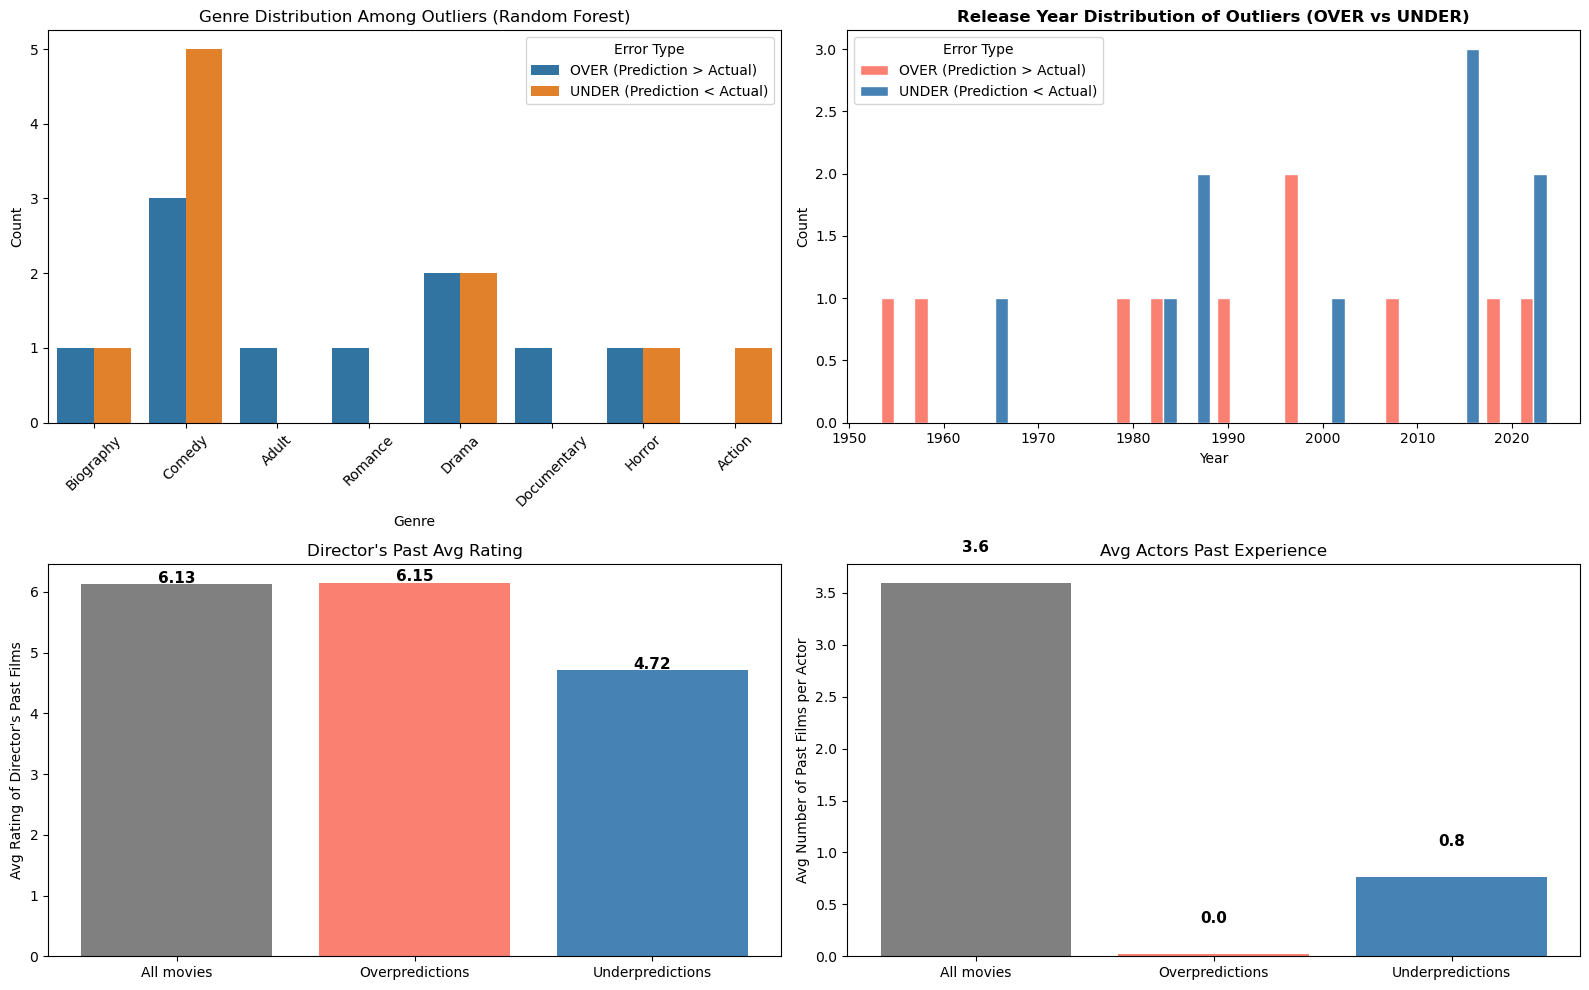

In [15]:
# 10.3 Pattern analysis 
# הגדרת סיווג השגיאה (חיובי = OVER, שלילי = UNDER) לצורך הצגה בגרף
outliers_rf['Error Type'] = outliers_rf['error_rf'].apply(
    lambda x: 'OVER (Prediction > Actual)' if x >= 0 else 'UNDER (Prediction < Actual)')
FEAT_COLS = ['director_past_avg', 'avg_actors_past_exp']
groups    = ['All movies', 'Overpredictions', 'Underpredictions']
colors    = ['gray', 'salmon', 'steelblue']

all_means   = errors_df[FEAT_COLS].mean()
over_means  = over_rf[FEAT_COLS].mean()
under_means = under_rf[FEAT_COLS].mean()

# גרף 2×2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.countplot(data=outliers_rf, x='first_genre', hue='Error Type', ax=axes[0,0])
axes[0, 0].set_title('Genre Distribution Among Outliers (Random Forest)')
axes[0, 0].set_xlabel('Genre')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

outliers_over_years  = errors_df.loc[over_rf.index, 'startYear'].dropna()
outliers_under_years = errors_df.loc[under_rf.index, 'startYear'].dropna()

axes[0, 1].hist([outliers_over_years, outliers_under_years], 
    bins=20, color=['salmon', 'steelblue'], 
    label=['OVER (Prediction > Actual)', 'UNDER (Prediction < Actual)'], 
    edgecolor='white')
# הגדרות כותרות וצירים 
axes[0, 1].set_title('Release Year Distribution of Outliers (OVER vs UNDER)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(title='Error Type')

dir_vals = [all_means['director_past_avg'],
            over_means['director_past_avg'],
            under_means['director_past_avg']]
bars = axes[1, 0].bar(groups, dir_vals, color=colors)
axes[1, 0].set_title("Director's Past Avg Rating")
axes[1, 0].set_ylabel("Avg Rating of Director's Past Films")
for bar, v in zip(bars, dir_vals):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    v + 0.02, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

act_vals = [all_means['avg_actors_past_exp'],
            over_means['avg_actors_past_exp'],
            under_means['avg_actors_past_exp']]
bars = axes[1, 1].bar(groups, act_vals, color=colors)
axes[1, 1].set_title('Avg Actors Past Experience')
axes[1, 1].set_ylabel('Avg Number of Past Films per Actor')
for bar, v in zip(bars, act_vals):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                    v + 0.3, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

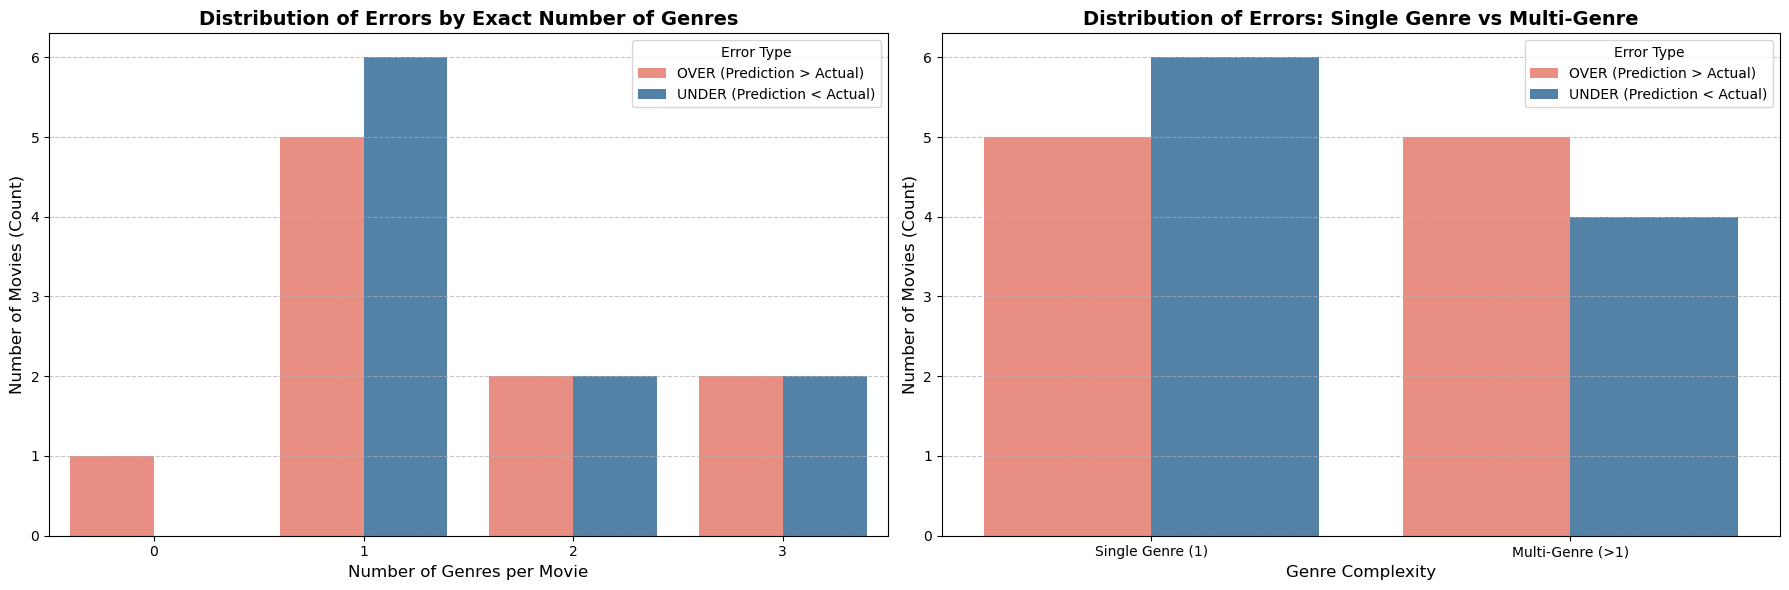

In [16]:

palette_colors = {'OVER (Prediction > Actual)': 'salmon', 'UNDER (Prediction < Actual)': 'steelblue'}
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# גרף א': חלוקת השגיאות לפי מספר הז'אנרים המדויק (num_genres)
sns.countplot(data=outliers_rf, x='num_genres', hue='Error Type', palette=palette_colors, ax=axes[0])
axes[0].set_title('Distribution of Errors by Exact Number of Genres', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Genres per Movie', fontsize=12)
axes[0].set_ylabel('Number of Movies (Count)', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(title='Error Type')

# גרף ב': חלוקה לפי מורכבות - ז'אנר יחיד (1) מול ריבוי ז'אנרים (גדול מ-1)
sns.countplot(
    data=outliers_rf, 
    x=outliers_rf['num_genres'].apply(lambda x: 'Single Genre (1)' if x == 1 else 'Multi-Genre (>1)'), 
    hue='Error Type', 
    palette=palette_colors, 
    ax=axes[1],
    order=['Single Genre (1)', 'Multi-Genre (>1)'])
axes[1].set_title('Distribution of Errors: Single Genre vs Multi-Genre', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Genre Complexity', fontsize=12)
axes[1].set_ylabel('Number of Movies (Count)', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(title='Error Type')

plt.tight_layout()
plt.show()

In [17]:
### 10.4 – השוואה בין המודלים
overlap_idx = outliers_rf.index.intersection(outliers_en.index)
print(f"חפיפה בין המודלים: {len(overlap_idx)} סרטים מתוך 20")
print(f"\nסרטים שמופיעים אצל שניהם:")
display(errors_df.loc[overlap_idx, ['primaryTitle', 'y_true', 'pred_rf', 'pred_en', 'error_rf', 'error_en']].round(2))


חפיפה בין המודלים: 10 סרטים מתוך 20

סרטים שמופיעים אצל שניהם:


,primaryTitle,y_true,pred_rf,pred_en,error_rf,error_en
8633,Young Bess,1.0,7.26,6.85,6.26,5.85
43217,Unmade Beds,1.7,7.80,7.38,6.10,5.68
12414,Beyond the Time Barrier,1.2,7.12,7.14,5.92,5.94
43273,Guidao,1.4,7.29,7.22,5.89,5.82
30164,Afternoon Affair,1.5,7.24,7.15,5.74,5.65
60471,All Together Now,1.3,6.91,6.87,5.61,5.57
81756,Cat Sick Blues,8.9,4.32,4.32,-4.58,-4.58
14891,Trzy kroki po ziemi,8.1,3.66,3.24,-4.44,-4.86
104047,Hareesha Vayassu 36,8.7,4.31,4.22,-4.39,-4.48
84762,Middle Man,8.8,4.43,4.10,-4.37,-4.70


In [19]:
# מה שייחודי לכל מודל
only_rf = outliers_rf.index.difference(outliers_en.index)
only_en = outliers_en.index.difference(outliers_rf.index)
# השוואת שגיאות לפי כול מיני נתונים 
sub_best  = errors_df.loc[only_best]
sub_other = errors_df.loc[only_other]
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
# [0,0] – ז'אנר: שני המודלים על אותו גרף
genre_best  = sub_best['first_genre'].value_counts().head(6)
genre_other = sub_other['first_genre'].value_counts().head(6)
all_genres  = sorted(set(genre_best.index) | set(genre_other.index))
x = range(len(all_genres))
w = 0.35
axes[0, 0].bar([i - w/2 for i in x],
               [genre_best.get(g, 0)  for g in all_genres], w,
               label=f'{best_name} Unique',  color='salmon')
axes[0, 0].bar([i + w/2 for i in x],
               [genre_other.get(g, 0) for g in all_genres], w,
               label=f'{other_name} Unique', color='steelblue')
axes[0, 0].set_xticks(list(x))
axes[0, 0].set_xticklabels(all_genres, rotation=40, ha='right')
axes[0, 0].set_title('Genre – Unique Errors per Model')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()
# [0,1] – עשור: שני המודלים על אותו גרף
dec_best  = (sub_best['startYear']  // 10 * 10).value_counts().sort_index()
dec_other = (sub_other['startYear'] // 10 * 10).value_counts().sort_index()
all_dec   = sorted(set(dec_best.index) | set(dec_other.index))
dec_labels = [f"{int(d)}s" for d in all_dec]
x = range(len(all_dec))
axes[0, 1].bar([i - w/2 for i in x],
               [dec_best.get(d, 0)  for d in all_dec], w,
               label=f'{best_name} Unique',  color='salmon')
axes[0, 1].bar([i + w/2 for i in x],
               [dec_other.get(d, 0) for d in all_dec], w,
               label=f'{other_name} Unique', color='steelblue')
axes[0, 1].set_xticks(list(x))
axes[0, 1].set_xticklabels(dec_labels, rotation=40, ha='right')
axes[0, 1].set_title('Decade – Unique Errors per Model')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()
# [1,0] – Director Past Avg
overall_dir = errors_df['director_past_avg'].mean()
groups  = ['All movies', f'{best_name}\nUnique', f'{other_name}\nUnique']
dir_v   = [overall_dir,
           sub_best['director_past_avg'].mean(),
           sub_other['director_past_avg'].mean()]
colors  = ['gray', 'salmon', 'steelblue']
bars = axes[1, 0].bar(groups, dir_v, color=colors)
axes[1, 0].set_title("Director's Past Avg Rating – Unique Errors per Model")
axes[1, 0].set_ylabel("Avg Rating of Director's Past Films")
for bar, v in zip(bars, dir_v):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
# [1,1] – Actors Past Experience
overall_act = errors_df['avg_actors_past_exp'].mean()
act_v = [overall_act,
         sub_best['avg_actors_past_exp'].mean(),
         sub_other['avg_actors_past_exp'].mean()]
bars = axes[1, 1].bar(groups, act_v, color=colors)
axes[1, 1].set_title('Actors Past Experience – Unique Errors per Model')
axes[1, 1].set_ylabel('Avg Number of Past Films per Actor')
for bar, v in zip(bars, act_v):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                    v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')
# [2,0] – מספר ז'אנרים מדויק: שני המודלים על אותו גרף
num_genres_best  = sub_best['num_genres'].value_counts().sort_index()
num_genres_other = sub_other['num_genres'].value_counts().sort_index()
all_nums         = sorted(set(num_genres_best.index) | set(num_genres_other.index))
x_nums           = range(len(all_nums))

axes[2, 0].bar([i - w/2 for i in x_nums],
               [num_genres_best.get(n, 0)  for n in all_nums], w,
               label=f'{best_name} Unique',  color='salmon')
axes[2, 0].bar([i + w/2 for i in x_nums],
               [num_genres_other.get(n, 0) for n in all_nums], w,
               label=f'{other_name} Unique', color='steelblue')
axes[2, 0].set_xticks(list(x_nums))
axes[2, 0].set_xticklabels([str(n) for n in all_nums])
axes[2, 0].set_title('Number of Genres – Unique Errors per Model')
axes[2, 0].set_ylabel('Count')
axes[2, 0].set_xlabel('Number of Genres')
axes[2, 0].legend()

# [2,1] – מורכבות הז'אנר (בוליאני): ז'אנר יחיד מול ריבוי ז'אנרים
comp_best  = sub_best['num_genres'].apply(lambda x: 'Single Genre (1)' if x == 1 else 'Multi-Genre (>1)').value_counts()
comp_other = sub_other['num_genres'].apply(lambda x: 'Single Genre (1)' if x == 1 else 'Multi-Genre (>1)').value_counts()
all_comps  = ['Single Genre (1)', 'Multi-Genre (>1)']
x_comps    = range(len(all_comps))

axes[2, 1].bar([i - w/2 for i in x_comps],
               [comp_best.get(c, 0)  for c in all_comps], w,
               label=f'{best_name} Unique',  color='salmon')
axes[2, 1].bar([i + w/2 for i in x_comps],
               [comp_other.get(c, 0) for c in all_comps], w,
               label=f'{other_name} Unique', color='steelblue')
axes[2, 1].set_xticks(list(x_comps))
axes[2, 1].set_xticklabels(all_comps)
axes[2, 1].set_title('Genre Complexity – Unique Errors per Model')
axes[2, 1].set_ylabel('Count')
axes[2, 1].set_xlabel('Genre Complexity')
axes[2, 1].legend()
plt.tight_layout()
plt.show()

NameError: name 'only_best' is not defined

In [ ]:
# טבלת סיכום
summary_unique = pd.DataFrame({ 'Metric':              ['N (unique outliers)',
                            'Top Genre',
                            'Top Decade',
                            'Director Past Avg',
                            'Actors Past Exp',
                            'Avg Number of Genres',          
                            'Multi-Genre Movies (%)'],       
    f'{best_name} Unique': [
        len(sub_best),
        sub_best['first_genre'].value_counts().idxmax() if len(sub_best) > 0 else 'N/A',
        f"{int((sub_best['startYear'] // 10 * 10).value_counts().idxmax())}s" if len(sub_best) > 0 else 'N/A',
        f"{sub_best['director_past_avg'].mean():.2f}",
        f"{sub_best['avg_actors_past_exp'].mean():.1f}",
        f"{sub_best['num_genres'].mean():.2f}" if len(sub_best) > 0 else 'N/A',                                    
        f"{(sub_best['num_genres'] > 1).mean() * 100:.1f}%" if len(sub_best) > 0 else 'N/A',],
    f'{other_name} Unique': [
        len(sub_other),
        sub_other['first_genre'].value_counts().idxmax() if len(sub_other) > 0 else 'N/A',
        f"{int((sub_other['startYear'] // 10 * 10).value_counts().idxmax())}s" if len(sub_other) > 0 else 'N/A',
        f"{sub_other['director_past_avg'].mean():.2f}",
        f"{sub_other['avg_actors_past_exp'].mean():.1f}",
        f"{sub_other['num_genres'].mean():.2f}" if len(sub_other) > 0 else 'N/A',                                 
        f"{(sub_other['num_genres'] > 1).mean() * 100:.1f}%" if len(sub_other) > 0 else 'N/A',],
    'All movies': [
        len(errors_df),
        errors_df['first_genre'].value_counts().idxmax(),
        f"{int((errors_df['startYear'] // 10 * 10).value_counts().idxmax())}s",
        f"{errors_df['director_past_avg'].mean():.2f}",
        f"{errors_df['avg_actors_past_exp'].mean():.1f}",
        f"{errors_df['num_genres'].mean():.2f}",                                                                 
        f"{(errors_df['num_genres'] > 1).mean() * 100:.1f}%",],
}).set_index('Metric')

print("── Summary: Unique Errors per Model vs All movies ──")
display(summary_unique)

## 11. ניתוח הוגנות (Fairness Analysis)

In [ ]:
# ── 11.1 Setup ───────────────────────────────────────────────
fairness_df = errors_df.copy()
fairness_df['decade'] = (fairness_df['startYear'] // 10 * 10).astype('Int64')
overall_rmse = np.sqrt(mean_squared_error(fairness_df['y_true'], fairness_df['pred_rf']))
overall_mae  = mean_absolute_error(fairness_df['y_true'], fairness_df['pred_rf'])
def slice_metrics(df, label):
    rmse = np.sqrt(mean_squared_error(df['y_true'], df['pred_rf']))
    mae  = mean_absolute_error(df['y_true'], df['pred_rf'])
    pct  = (rmse / overall_rmse - 1) * 100
    return {'Slice': label, 'N': len(df),
            'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'RMSE vs overall': f'{pct:+.1f}%'}

In [ ]:
# ── 11.2 By Genre (top 5, multi-label) ───────────────────────
genre_rows = []
for _, row in fairness_df.iterrows():
    for g in (row['genres'] if isinstance(row['genres'], list) else []):
        genre_rows.append(row.to_dict() | {'genre_label': g})
genre_long  = pd.DataFrame(genre_rows)
top5_genres = genre_long['genre_label'].value_counts().head(5).index
genre_df = pd.DataFrame([
    slice_metrics(genre_long[genre_long['genre_label'] == g], g)
    for g in top5_genres
])

In [ ]:
# ── 11.3 By Decade ───────────────────────────────────────────
decade_df = pd.DataFrame([
    slice_metrics(sub, f"{int(decade)}s")
    for decade, sub in fairness_df.groupby('decade')
    if len(sub) >= 30
])
# ── Tables ───────────────────────────────────────────────────
print("── RMSE / MAE by Genre (top 5) ──")
display(genre_df)
print("\n── RMSE / MAE by Decade ──")
display(decade_df)
# ── Bar Charts ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(genre_df['Slice'], genre_df['RMSE'], color='steelblue')
axes[0].axhline(overall_rmse, color='red', linestyle='--',
                label=f'Overall RMSE = {overall_rmse:.3f}')
axes[0].set_title('RMSE by Genre (top 5)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()
axes[1].bar(decade_df['Slice'], decade_df['RMSE'], color='steelblue')
axes[1].axhline(overall_rmse, color='red', linestyle='--',
                label=f'Overall RMSE = {overall_rmse:.3f}')
axes[1].set_title('RMSE by Decade')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()
plt.tight_layout()
plt.show()

## 12. שמירת מודל סופי + prepare_data

### prepare_data

מקבלת רק את דאטת התחרות.
ניגשת ל-`df_train_global` שנשמר בזיכרון ה-notebook –
כך הפיצ'רים ההיסטוריים מחושבים על בסיס דאטת האימון.

<div dir="rtl">
כדי שבזמן הגנת הפרויקט הוא יוכל לטעון אותו בשנייה אחת ולבחון אותו על סרטים חדשים, בלי לחכות שהקוד יתאמן מחדש
הקוד הזה ייצור לך קובץ בשם model.pkl בתיקייה, ואותו את מעלה לגיטהאב.
</div>

In [ ]:
import joblib

# נשמור את המודל המוביל שלך (למשל, ה-Pipeline של ה-Random Forest)
joblib.dump(best_rf_model, 'model.pkl')
print("המודל נשמר בהצלחה כ-model.pkl!")